In [125]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [126]:
plt.rcParams["font.family"]="Times New Roman"
plt.rcParams["font.size"]=15
plt.rcParams["axes.labelsize"]=15
plt.rcParams["axes.titlesize"]=15
plt.rcParams["xtick.labelsize"]=15
plt.rcParams["ytick.labelsize"]=15
plt.rcParams["legend.fontsize"]=15

In [127]:
#Loading the dataset
df=pd.read_csv("data_banknote_authentication.txt",header=None)
df.head()

,0,1,2,3,4
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [128]:
#Shape of the dataset
df.shape

(1372, 5)

In [129]:
#Assigning name to the columns
df.columns=["Feature_1","Feature_2","Feature_3","Feature_4","Target"]

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  1372 non-null   float64
 1   Feature_2  1372 non-null   float64
 2   Feature_3  1372 non-null   float64
 3   Feature_4  1372 non-null   float64
 4   Target     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [131]:
df.isnull().sum()

Feature_1    0
Feature_2    0
Feature_3    0
Feature_4    0
Target       0
dtype: int64

In [132]:
df.describe()

,Feature_1,Feature_2,Feature_3,Feature_4,Target
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [133]:
df["Target"].value_counts()

Target
0    762
1    610
Name: count, dtype: int64

In [134]:
l=["Feature_1","Feature_2","Feature_3","Feature_4"]

In [135]:
#plotting histogram
def histogram(feature,i):
  plt.figure(figsize=(6,4))
  plt.hist(df[feature])
  plt.xlabel(feature)
  plt.ylabel("Frequency")
  plt.savefig(f'plots/histogram_{i+1}.eps',format='eps',dpi=600,bbox_inches='tight')
  plt.show()

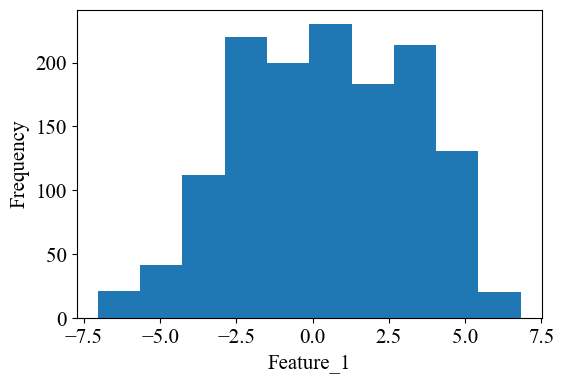

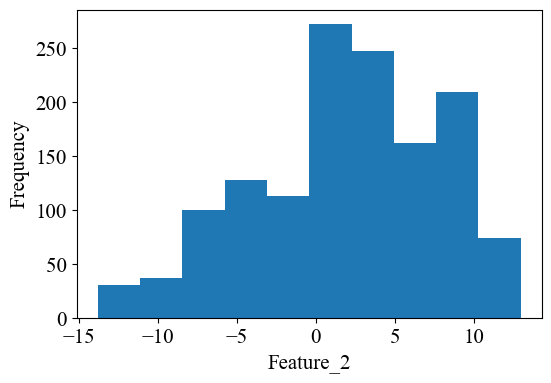

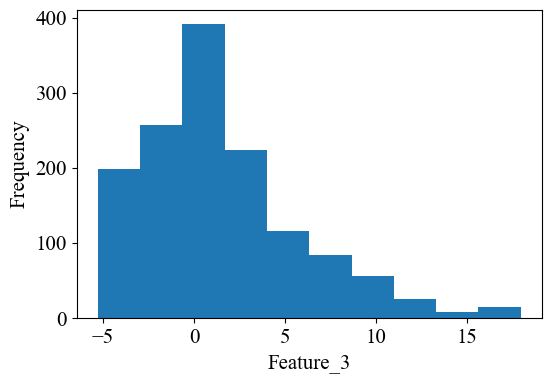

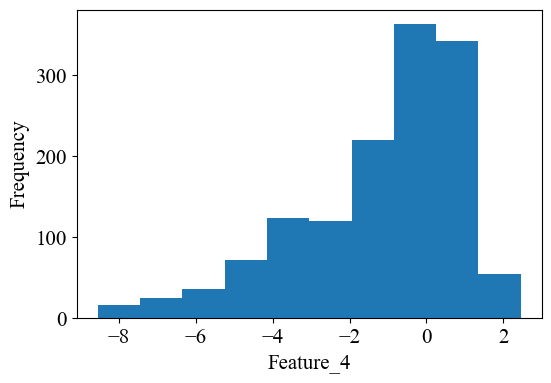

In [136]:
for i in range(len(l)):
  histogram(l[i],i)

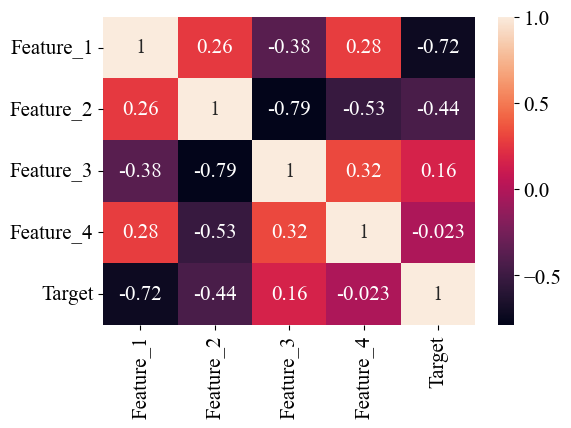

In [137]:
#correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(),annot=True)
plt.savefig("plots/heatmap.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [138]:
#Scatterplot for all combinations
def scatterplot(fea1,fea2,i,j):
  plt.figure(figsize=(6,4))
  sns.scatterplot(x=fea1,y=fea2,data=df,hue="Target")
  plt.savefig(f'plots/scatterplot_{i+1}_{j+1}.eps',format='eps',dpi=600,bbox_inches='tight')
  plt.show()

In [139]:
l1=l.copy()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


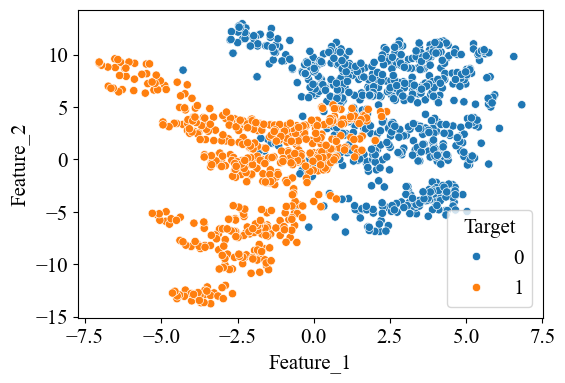

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


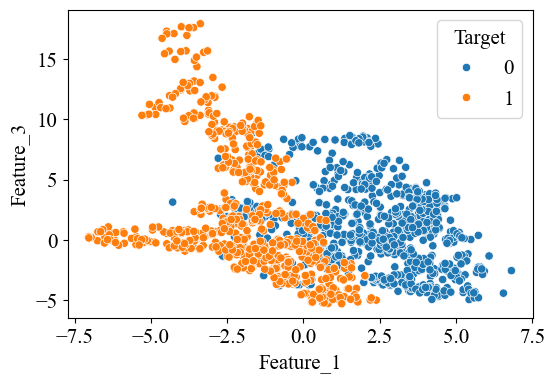

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


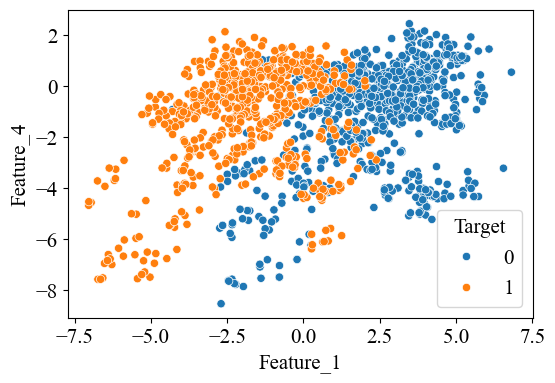

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


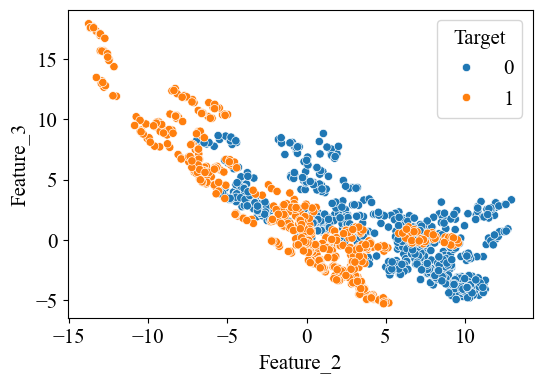

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


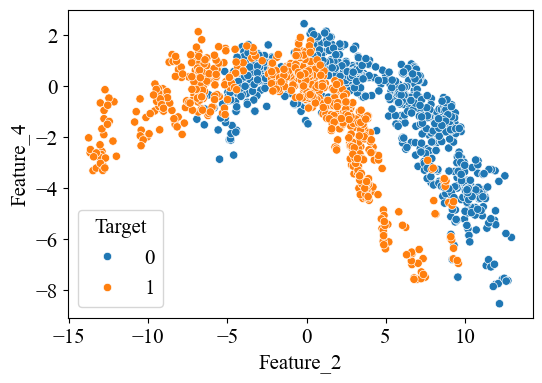

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


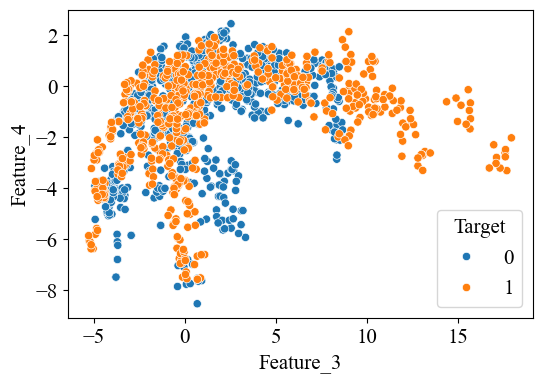

In [140]:
for i in range(len(l1)):
    for j in range(i+1,len(l1)):
        scatterplot(l1[i],l1[j],i,j)

In [141]:
#boxplot for all features
def boxplot(feature,i):
  plt.figure(figsize=(6,4))
  sns.boxplot(df[feature])
  plt.savefig(f'plots/boxplot_{i+1}.eps',format='eps',dpi=600,bbox_inches='tight')
  plt.show()

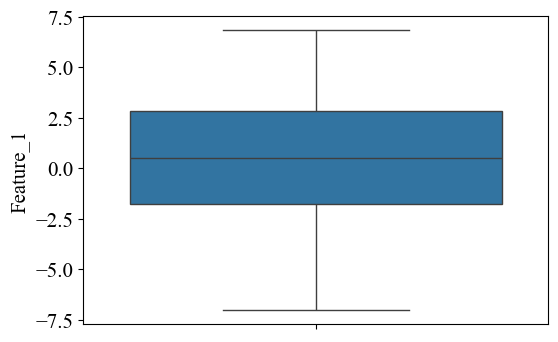

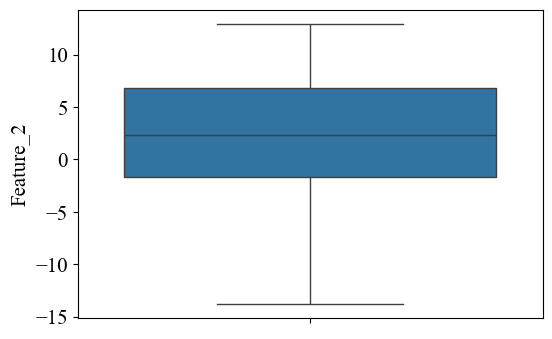

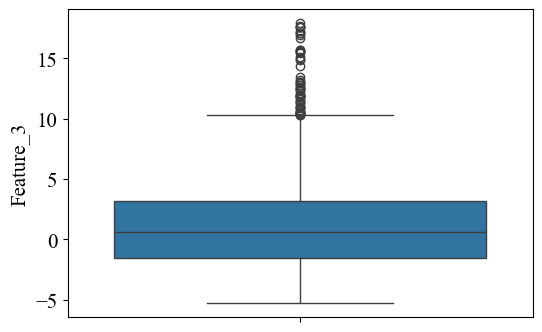

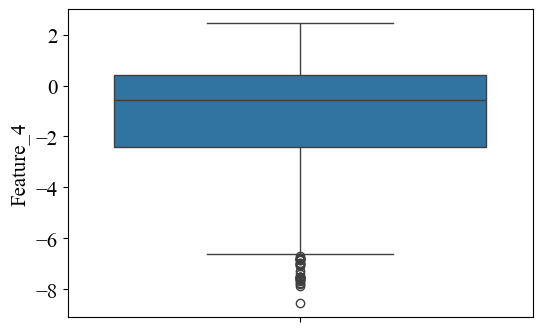

In [142]:
for i in range(len(l)):
  boxplot(l[i],i)

In [143]:
X=df[l]
y=df["Target"]

In [144]:
#Splitting the train and test data set
x_train,x_val,y_train,y_val=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [145]:
#Normalising the data using minmaxscaler
mm=MinMaxScaler()
x_train=mm.fit_transform(x_train)
x_val=mm.transform(x_val)

In [146]:
#Step activation function
def activation_fun(x):
  if x>=0:
    return 1
  else:
    return 0

In [147]:
#Function for forward propogation
def forward_prop(x_train,w1,w2,w3,w4,b):
  z=w1*x_train[0]+w2*x_train[1]+w3*x_train[2]+w4*x_train[3]+b
  a=activation_fun(z)
  return a

In [148]:
#Returns if the actual and predicted value are true or false
def error_rate(x,y):
  if x==y:
    return 1
  else:
    return 0

In [149]:
#Updating weights for misclassified data points
def weights_update(x_train,y_train,w1,w2,w3,w4,b,lr,mis_classified_cnt):
  a=forward_prop(x_train,w1,w2,w3,w4,b)
  error=error_rate(a,y_train)
  if error==1:
    return mis_classified_cnt,w1,w2,w3,w4,b,0
  else:
    mis_classified_cnt+=1
    #Weight updation
    w1=w1+lr*(y_train-a)*x_train[0]
    w2=w2+lr*(y_train-a)*x_train[1]
    w3=w3+lr*(y_train-a)*x_train[2]
    w4=w4+lr*(y_train-a)*x_train[3]
    b=b+lr*(y_train-a)
    return mis_classified_cnt,w1,w2,w3,w4,b,1

In [150]:
#Passing every data points to the forward progation and performing weight updation
def epoch_loop(x_train,y_train,w1,w2,w3,w4,b,lr):
  mis_classified_cnt=0
  mis_classified_pts=list()
  for i in range(x_train.shape[0]):
    mis_classified_cnt,w1,w2,w3,w4,b,check=weights_update(x_train[i],y_train.iloc[i],w1,w2,w3,w4,b,lr,mis_classified_cnt)
    if check==0:
      continue
    mis_classified_pts.append(i)
  return mis_classified_cnt,w1,w2,w3,w4,b,mis_classified_pts

In [151]:
max_epoch=100

In [152]:
#Initialising variables for storing best parameters
best_misclassified=float('inf')
best_lr=None
best_weights=None
best_bias=None
best_misclassified_pts=None
best_misclassified_count=None

In [153]:
#Performing multiple epochs until epoch reaching 100 or number of missclassified points becoming 0
def train(x_train,y_train,w1,w2,w3,w4,b,lr):
  mis_classified_cnt=0
  mis_classified_pts=list()
  mis_classified_count=list()

  w1_hist=[]
  w2_hist=[]
  w3_hist=[]
  w4_hist=[]
  b_hist =[]

  best_epoch_error=float('inf')
  best_w=None
  best_b=None
  best_pts=None
  i=1
  while(1):
    w1_prev,w2_prev,w3_prev,w4_prev,b_prev=w1,w2,w3,w4,b
    mis_classified_cnt,w1,w2,w3,w4,b,mis_classified_pts=epoch_loop(x_train,y_train,w1_prev,w2_prev,w3_prev,w4_prev,b_prev,lr)
    mis_classified_count.append(mis_classified_cnt)

    w1_hist.append(w1)
    w2_hist.append(w2)
    w3_hist.append(w3)
    w4_hist.append(w4)
    b_hist.append(b)

    if mis_classified_cnt<best_epoch_error:
      best_epoch_error=mis_classified_cnt
      best_w=[w1,w2,w3,w4]
      best_b=b
      best_pts=mis_classified_pts.copy()
    print("Epoch: ",i,"weights: ",[w1,w2,w3,w4],"\nbias: ",b,"\nMisclassified points count",mis_classified_cnt)
    i+=1
    if mis_classified_cnt==0:
      return best_w[0],best_w[1],best_w[2],best_w[3],best_b,best_epoch_error,best_pts,mis_classified_count, w1_hist, w2_hist, w3_hist, w4_hist, b_hist
    elif i>max_epoch:
      return best_w[0],best_w[1],best_w[2],best_w[3],best_b,best_epoch_error,best_pts,mis_classified_count, w1_hist, w2_hist, w3_hist, w4_hist, b_hist

In [154]:
w1_new=w2_new=w3_new=w4_new=b_new=0
mis_classified_cnt=0

In [155]:
#Performing forward propogation and weight updation for multiple learning rates
lr=[0.001,0.01,0.1]
mis_classified_count=list()
mis_classified_list=list()

weight1_histories=[]
weight2_histories=[]
weight3_histories=[]
weight4_histories=[]
bias_histories=[]

for num in lr:
  w1=w2=w3=w4=0.0
  b=0.0
  mis_classified_cnt=0
  mis_classified_pts=list()
  print("Learning rate: ",num,"\n\n")
  w1,w2,w3,w4,b,mis_classified_cnt,mis_classified_pts,mis_classified_count,w1_h,w2_h,w3_h,w4_h,b_h=train(x_train,y_train,w1,w2,w3,w4,b,num)
  mis_classified_list.append(mis_classified_count)
  weight1_histories.append(w1_h)
  weight2_histories.append(w2_h)
  weight3_histories.append(w3_h)
  weight4_histories.append(w4_h)
  bias_histories.append(b_h)

  if mis_classified_cnt<best_misclassified:
    best_misclassified=mis_classified_cnt
    best_lr=num
    best_weights=[w1,w2,w3,w4]
    best_bias=b
    best_misclassified_pts=mis_classified_pts.copy()
    best_misclassified_count=mis_classified_count.copy()
  print("Learning_rate: ",num,"\nFinal weights: ",[w1,w2,w3,w4],"\nFinal bias: ",b,"\nFinal misclassified points count",mis_classified_cnt,"\nFinal Misclassified points",mis_classified_pts)

Learning rate:  0.001 


Epoch:  1 weights:  [np.float64(-0.007529561336708277), np.float64(-0.005477985122377424), np.float64(-0.006564071207096559), np.float64(0.0019077793045350314)] 
bias:  0.008 
Misclassified points count 192
Epoch:  2 weights:  [np.float64(-0.0082821989990553), np.float64(-0.007188328924178752), np.float64(-0.008476376985341998), np.float64(0.0016992768849159942)] 
bias:  0.010000000000000002 
Misclassified points count 78
Epoch:  3 weights:  [np.float64(-0.0089162044364638), np.float64(-0.007808857723379493), np.float64(-0.009473968053405321), np.float64(0.0004676220901390015)] 
bias:  0.011000000000000003 
Misclassified points count 43
Epoch:  4 weights:  [np.float64(-0.009461209448398691), np.float64(-0.00854227010967382), np.float64(-0.009696995217498174), np.float64(0.00025556705199607054)] 
bias:  0.012000000000000004 
Misclassified points count 39
Epoch:  5 weights:  [np.float64(-0.009762466557053106), np.float64(-0.009681565967064182), np.float64(-0.0103

In [156]:
print(len(weight1_histories))
print(len(mis_classified_count))

3
100


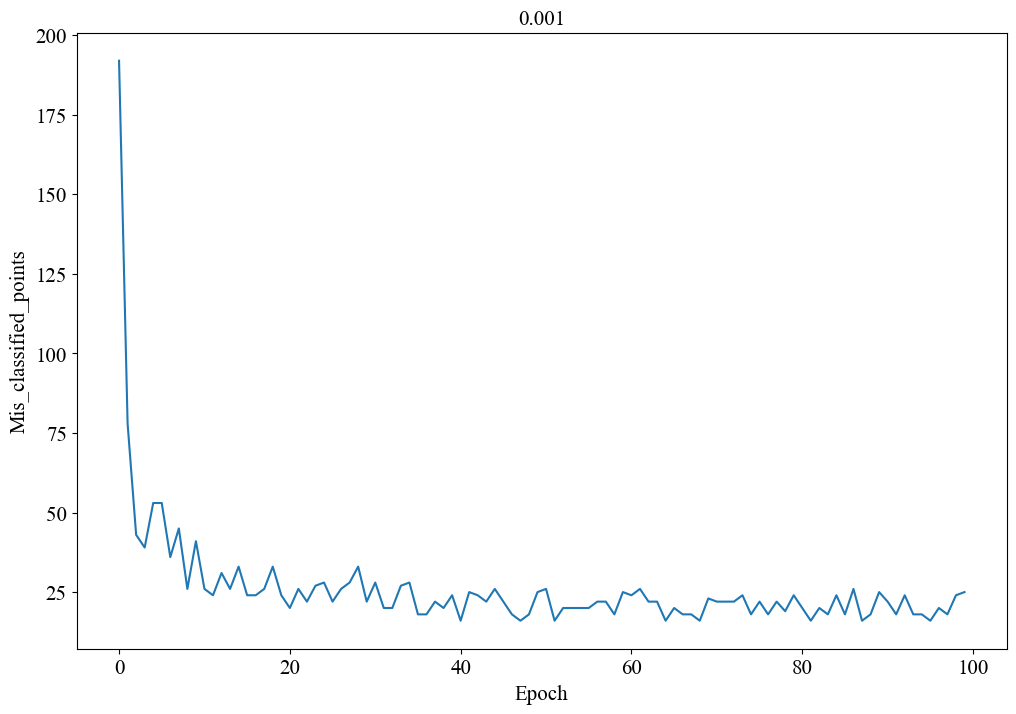

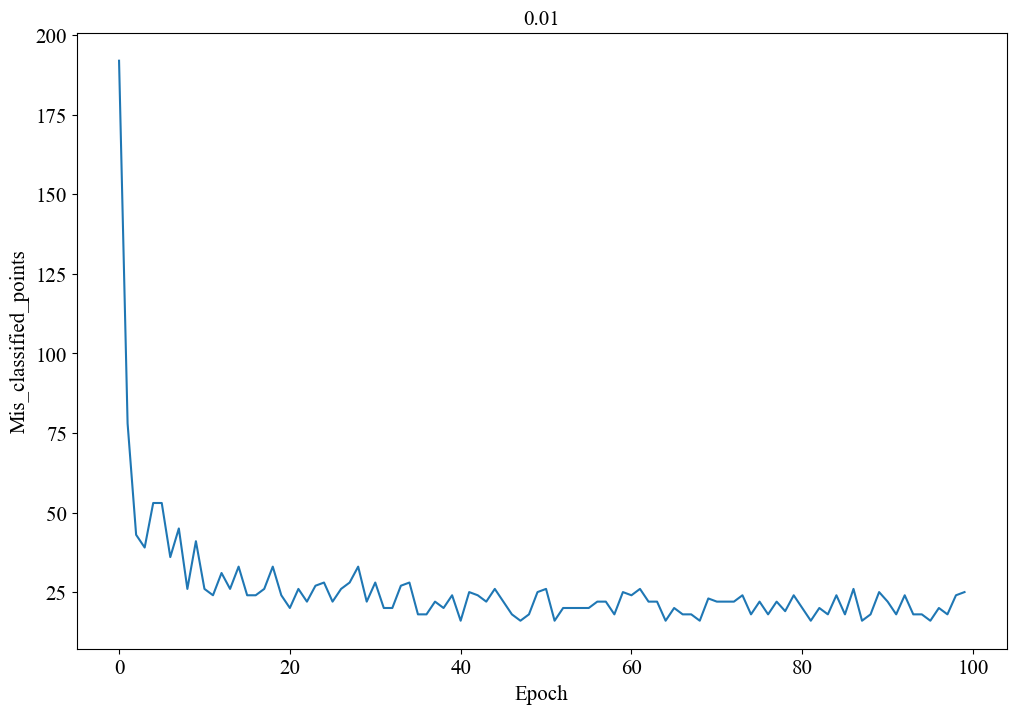

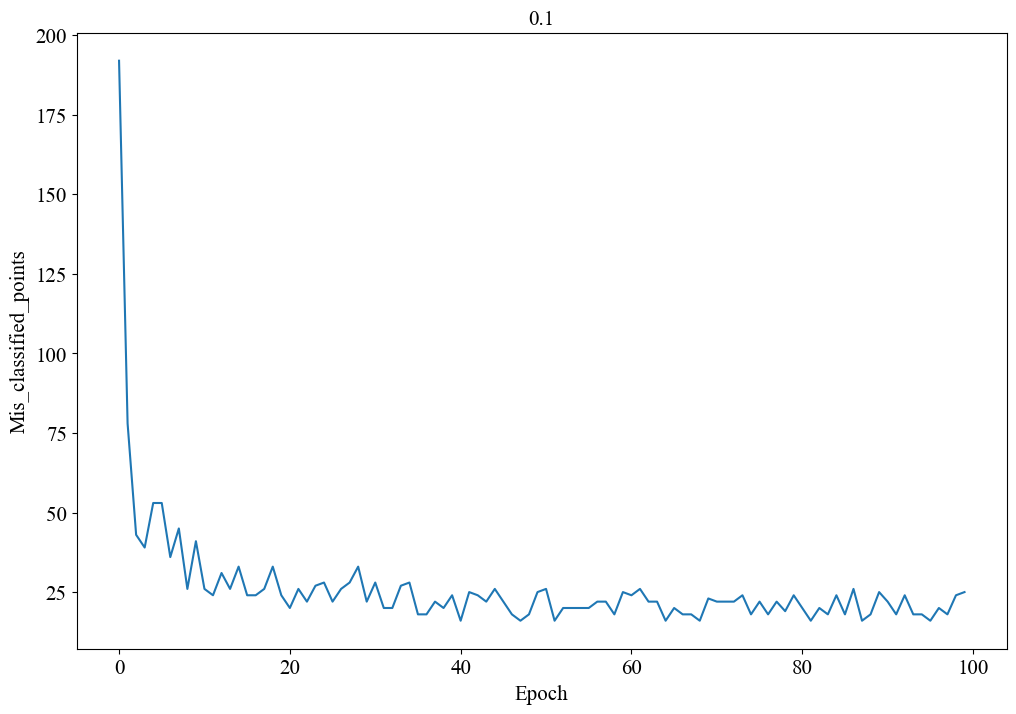

In [157]:
#Plotting numer of epochs vs missclassified points
for i in range(len(mis_classified_list)):
  plt.figure(figsize=(12,8))
  plt.plot(mis_classified_list[i])
  plt.xlabel("Epoch")
  plt.ylabel("Mis_classified_points")
  plt.title(lr[i])
  plt.savefig(f'plots/training_error_{lr[i]}.eps',format='eps',dpi=600,bbox_inches='tight')
  plt.show()

In [158]:
#Lisiting best parameters
print("Best learning rate:",best_lr)
print("Best weights:",best_weights)
print("Best bias:",best_bias)
print("Minimum Misclassified Samples:",best_misclassified)
print("Misclassified Points:",best_misclassified_pts)

Best learning rate: 0.001
Best weights: [np.float64(-0.015552388212217485), np.float64(-0.01819735267374384), np.float64(-0.01774085317417528), np.float64(0.00010315975101792289)]
Best bias: 0.022000000000000013
Minimum Misclassified Samples: 16
Misclassified Points: [156, 179, 200, 316, 357, 438, 446, 456, 690, 698, 780, 789, 868, 874, 968, 1010]


In [159]:
y_predicted=[]

In [160]:
#Model training with best possible parameters from our result
def final_train(x_train,y_train,w1,w2,w3,w4,b,lr):
  w1=best_weights[0]
  w2=best_weights[1]
  w3=best_weights[2]
  w4=best_weights[3]
  b=best_bias
  for i in range(x_val.shape[0]):
    y_predicted.append(forward_prop(x_val[i],w1,w2,w3,w4,b))

In [161]:
final_train(x_val,y_val,w1,w2,w3,w4,b,best_lr)

In [162]:
#Final test evaluation metrics
print("Accuracy_score: ",accuracy_score(y_val,y_predicted))
print("Precision_score: ",precision_score(y_val,y_predicted))
print("Recall_score: ",recall_score(y_val,y_predicted))
print("F1_score: ",f1_score(y_val,y_predicted))

Accuracy_score:  0.9890909090909091
Precision_score:  0.9917355371900827
Recall_score:  0.9836065573770492
F1_score:  0.9876543209876543


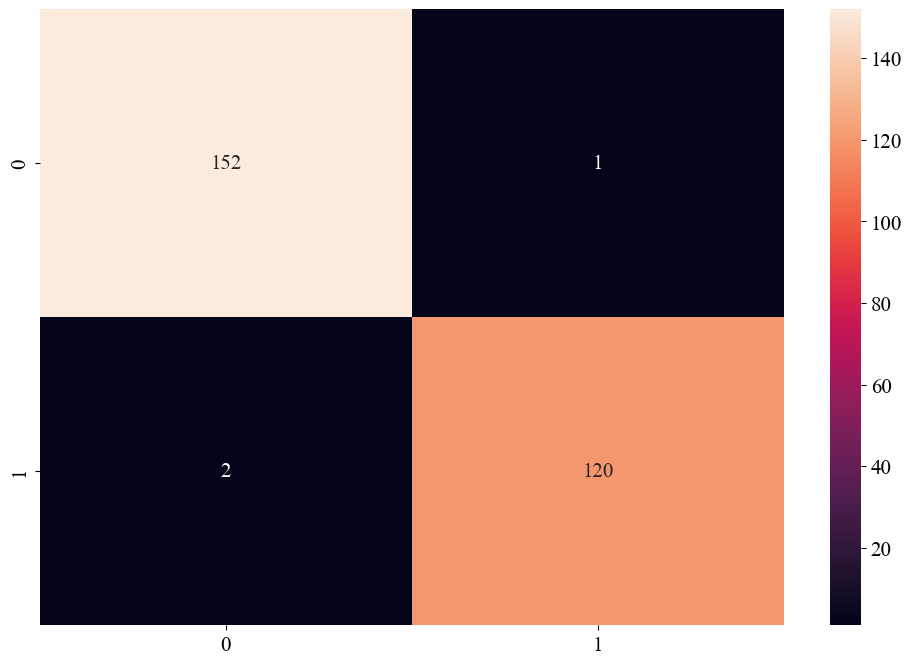

In [163]:
#Confusion matrix
plt.figure(figsize=(12,8))
sns.heatmap(confusion_matrix(y_val,y_predicted),annot=True,fmt="g")
plt.savefig('plots/confusion_matrix.eps',format='eps',dpi=600,bbox_inches='tight')
plt.show()

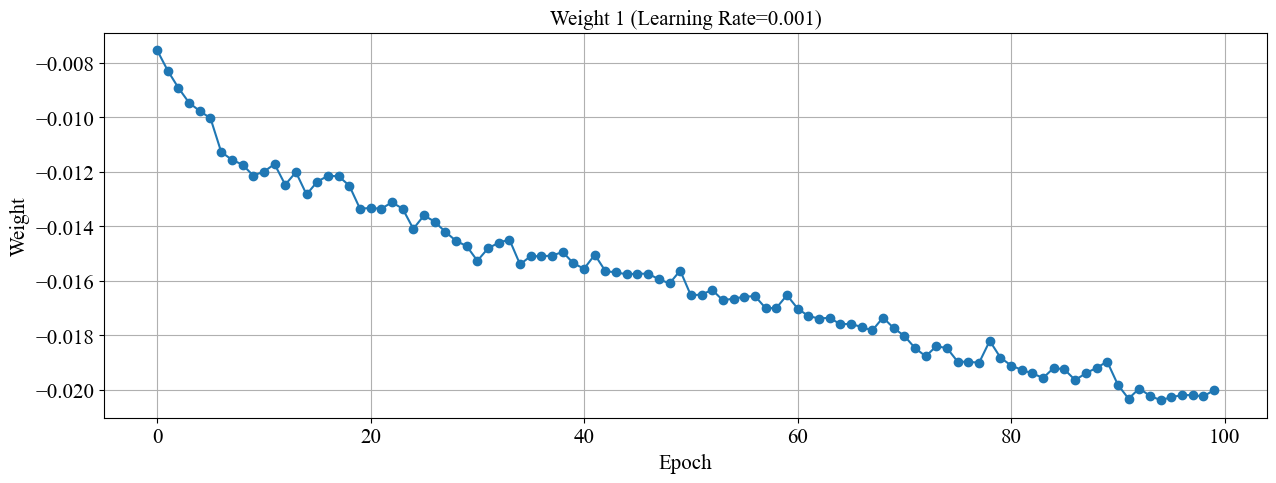

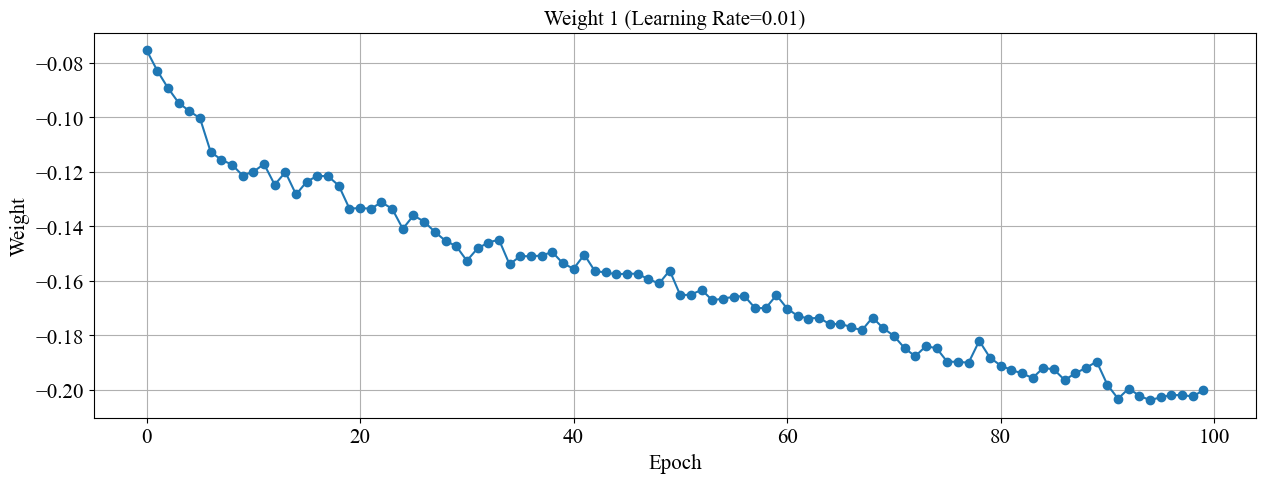

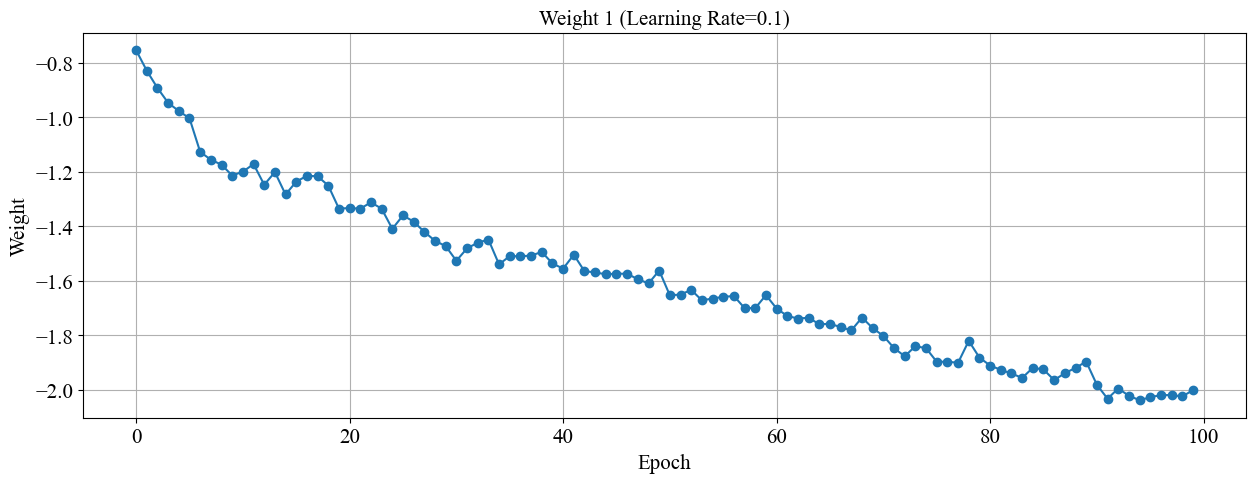

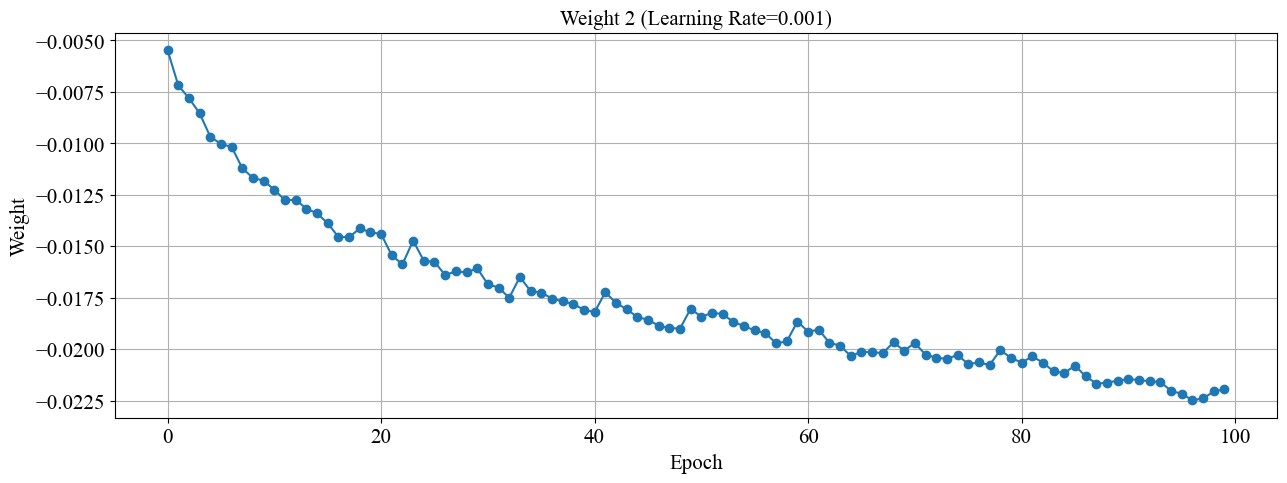

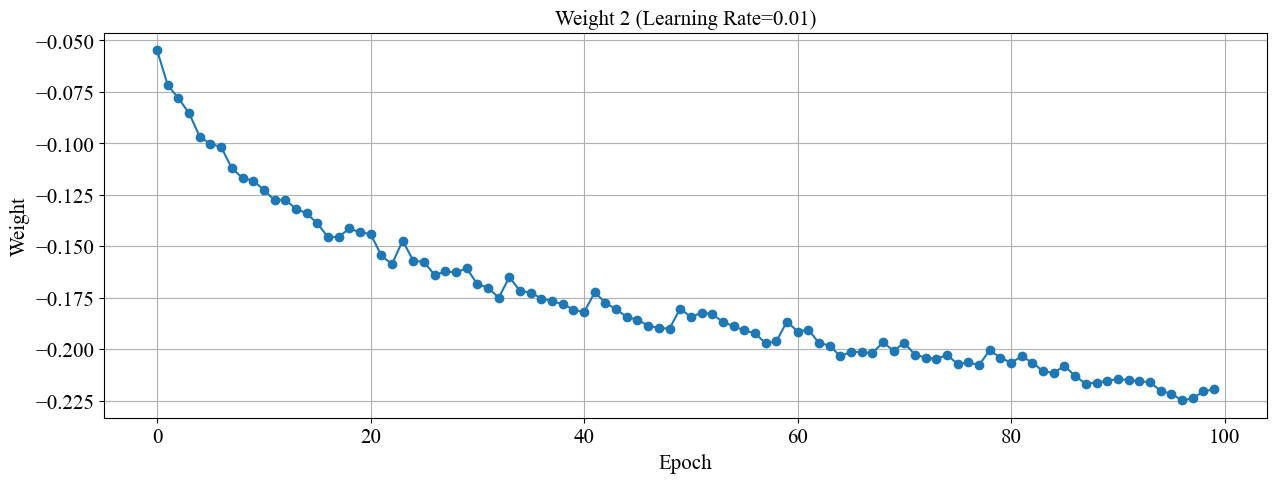

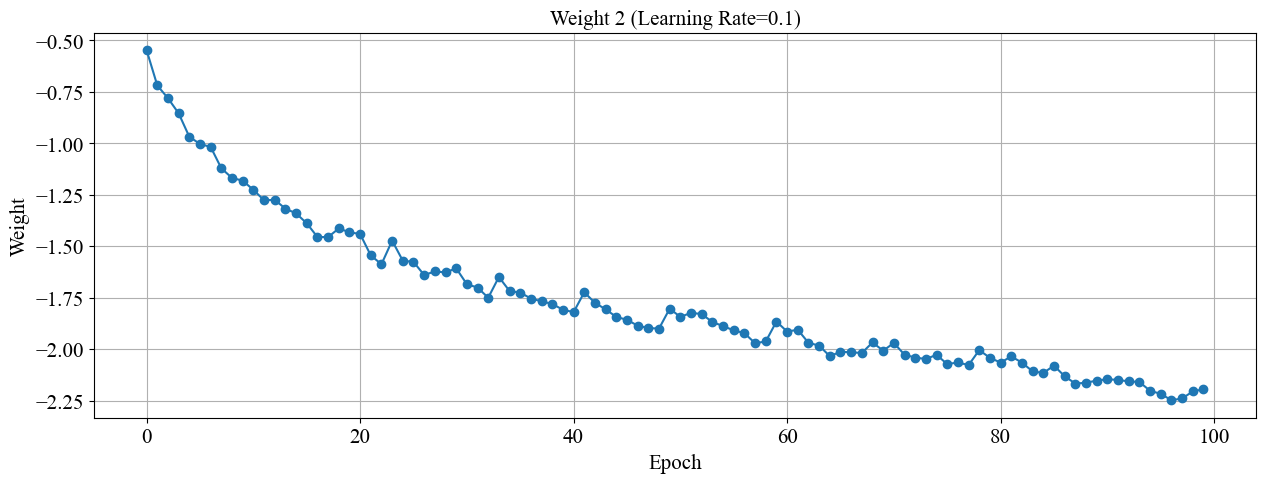

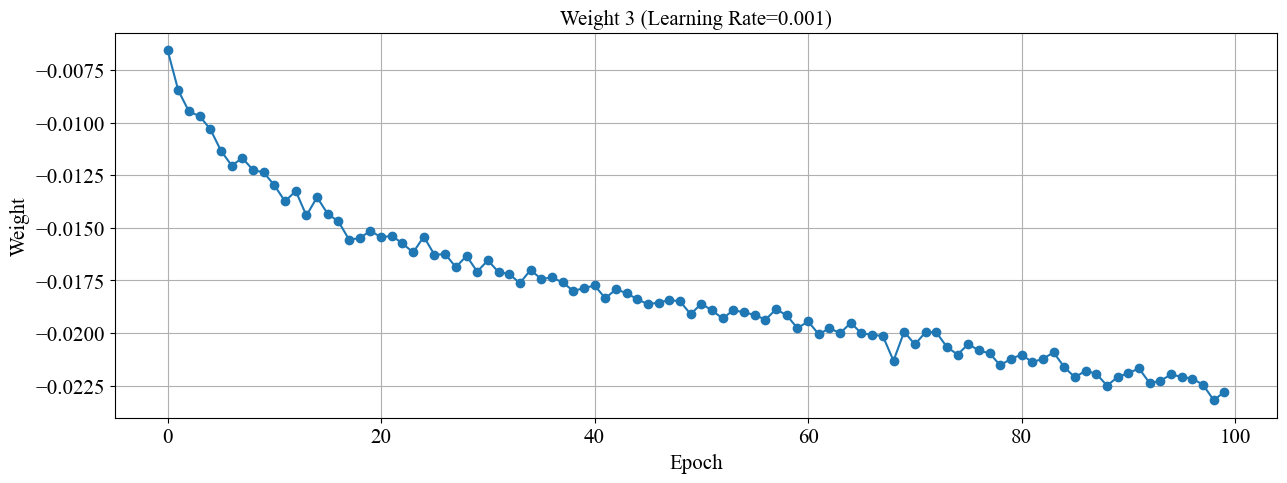

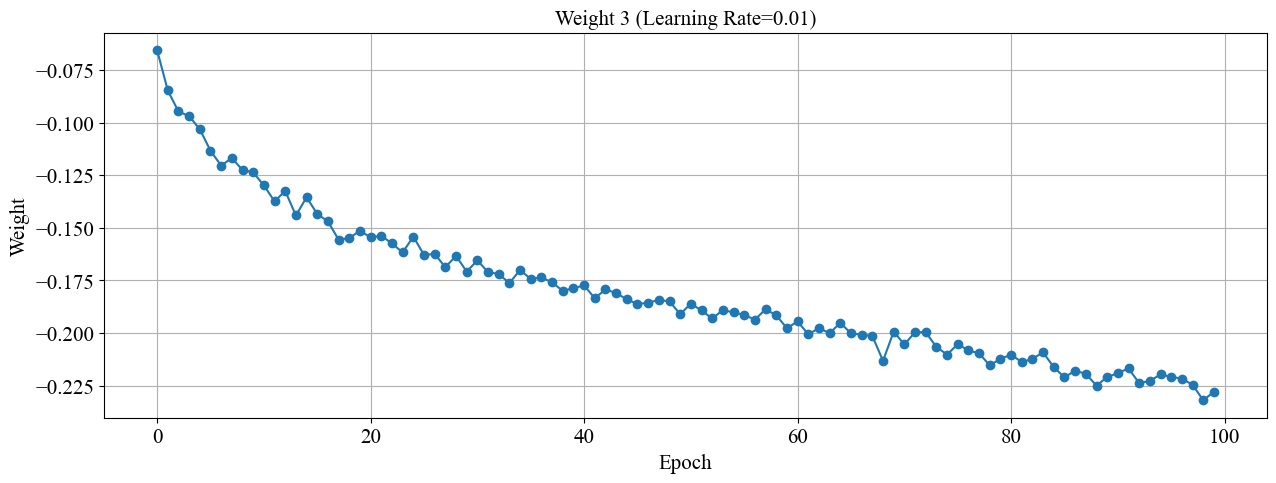

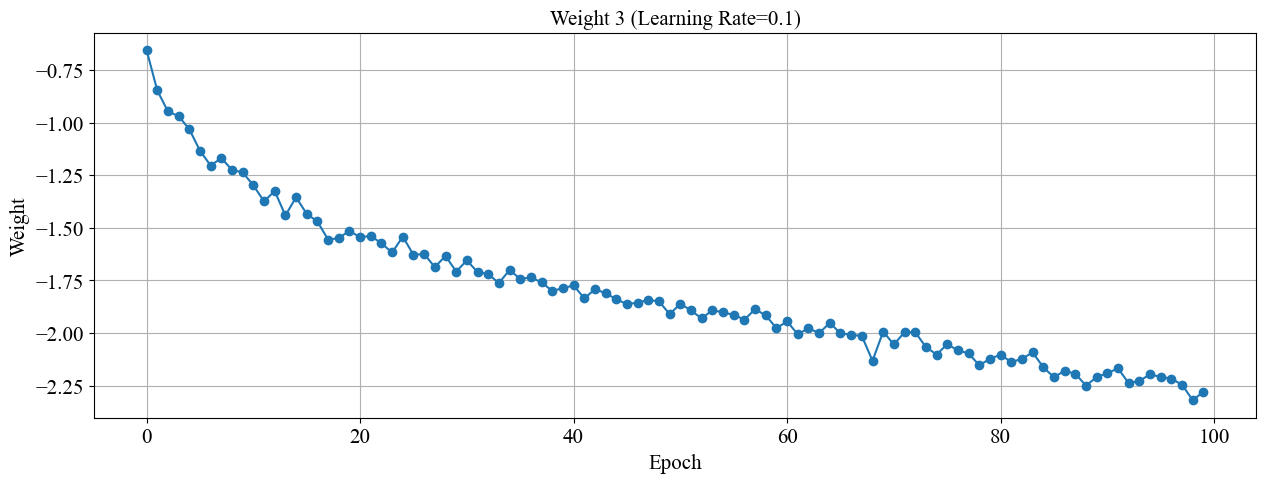

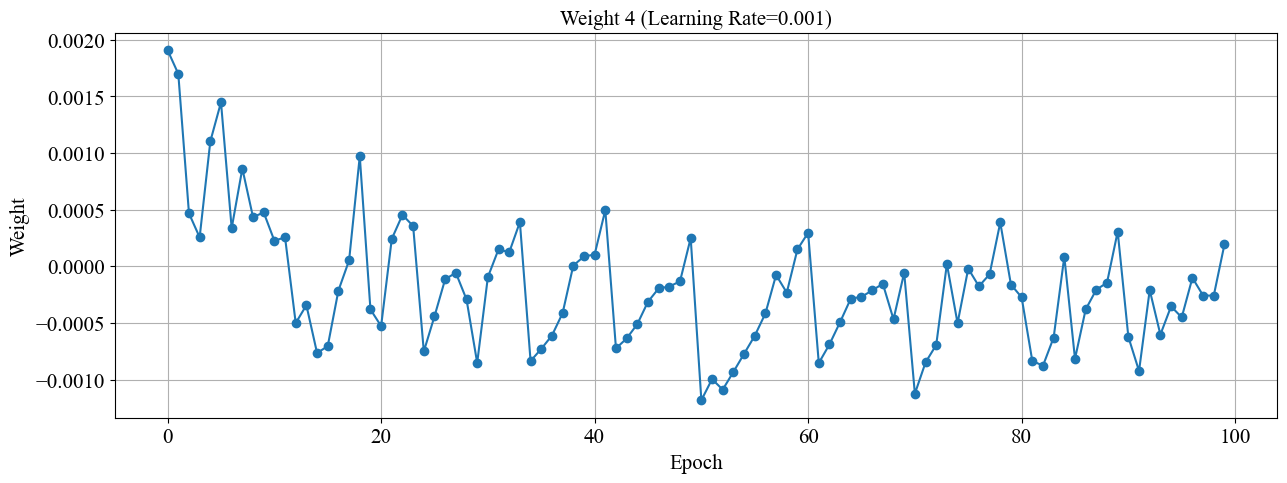

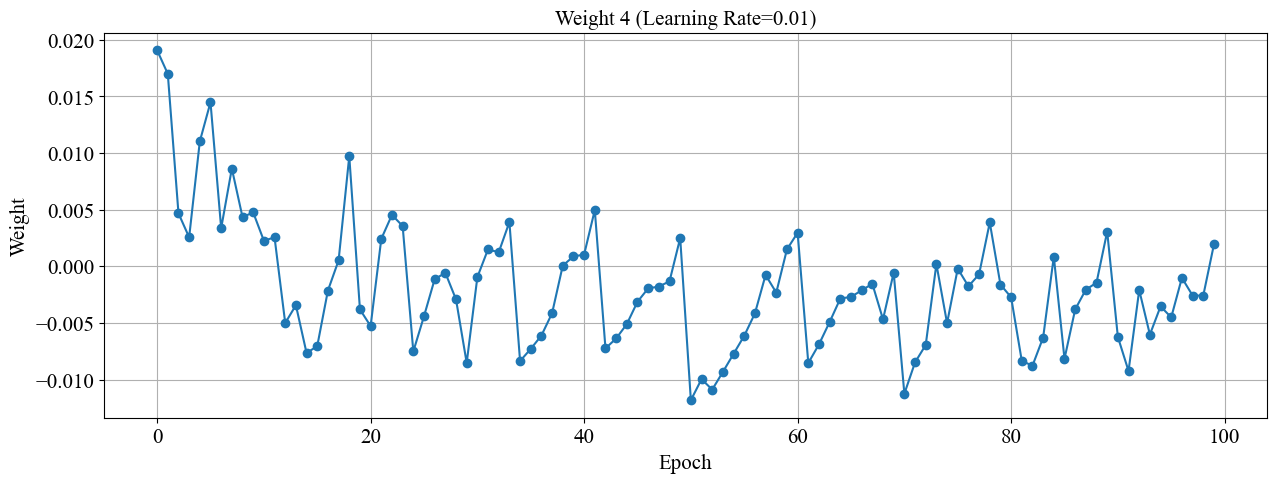

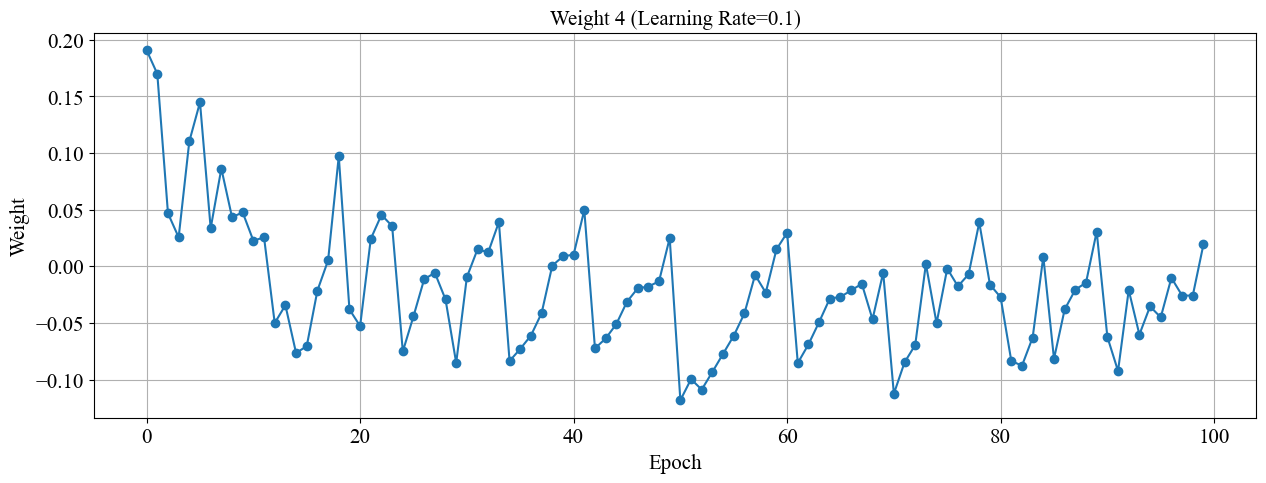

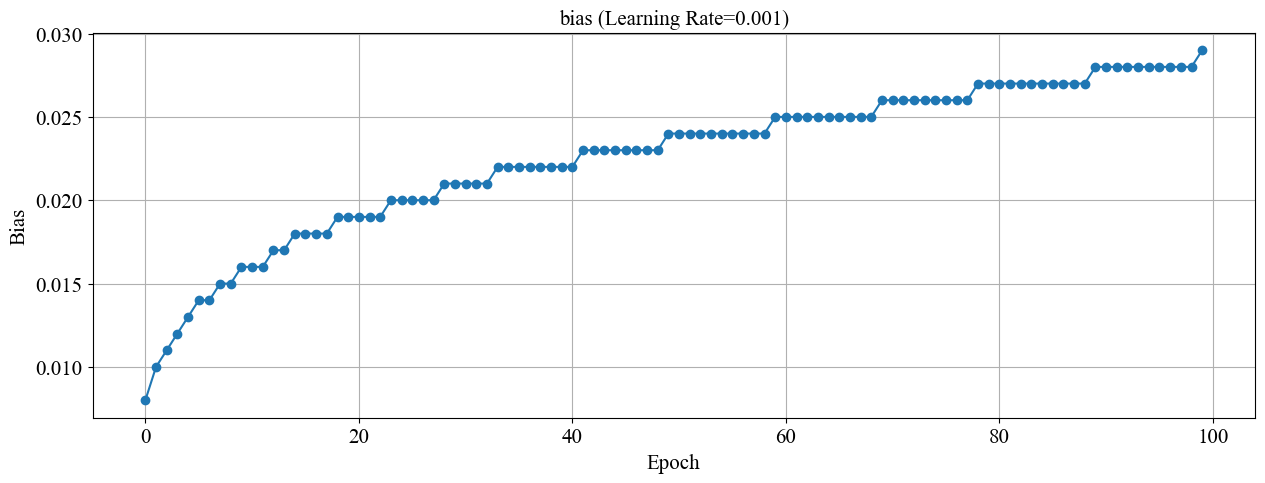

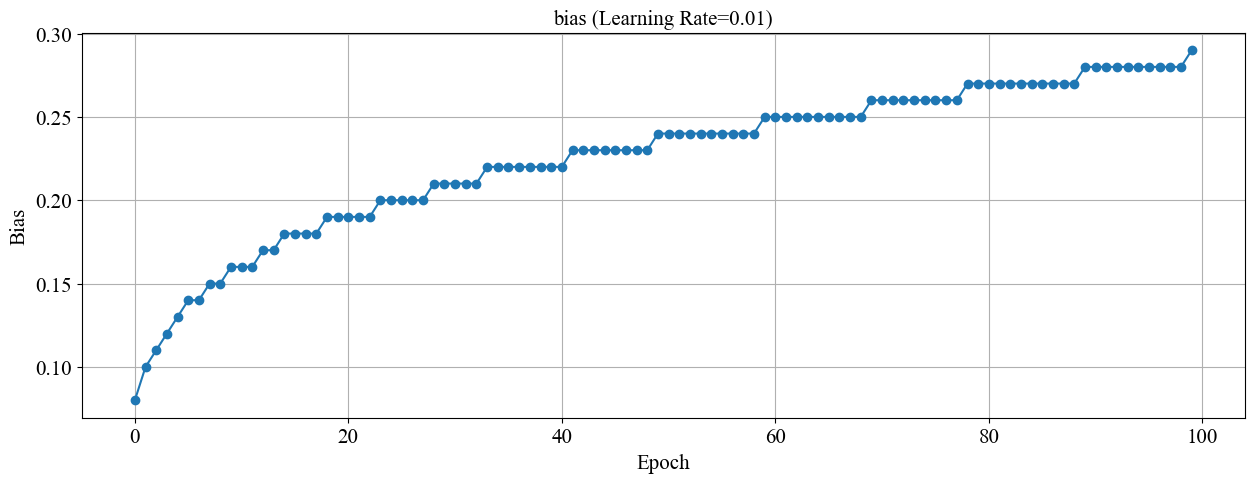

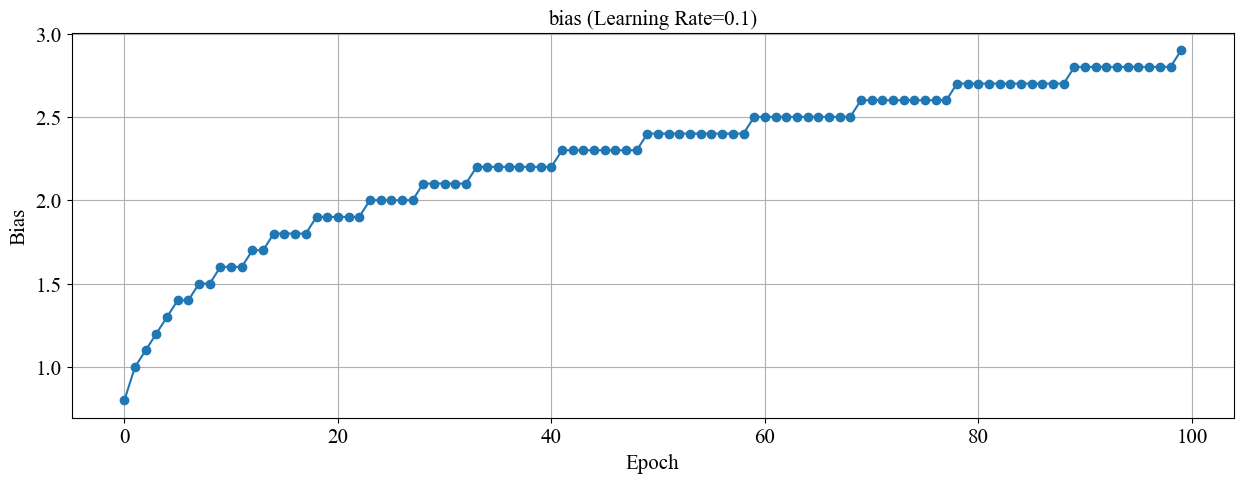

In [164]:
#Weight and bias progress for all features with different learning rate
for i in range(len(weight1_histories)):
    plt.figure(figsize=(15,5))
    plt.plot(weight1_histories[i],marker='o')
    plt.title(f"Weight 1 (Learning Rate={lr[i]})")
    plt.grid(True)
    plt.xlabel("Epoch")
    plt.ylabel("Weight")
    plt.savefig(f'plots/weight_progress_1_{lr[i]}.eps',format='eps',dpi=600,bbox_inches='tight')
    plt.show()

for i in range(len(weight2_histories)):
    plt.figure(figsize=(15,5))
    plt.plot(weight2_histories[i],marker='o')
    plt.title(f"Weight 2 (Learning Rate={lr[i]})")
    plt.grid(True)
    plt.xlabel("Epoch")
    plt.ylabel("Weight")
    plt.savefig(f'plots/weight_progress_2_{lr[i]}.eps',format='eps',dpi=600,bbox_inches='tight')
    plt.show()

for i in range(len(weight3_histories)):
    plt.figure(figsize=(15,5))
    plt.plot(weight3_histories[i],marker='o')
    plt.title(f"Weight 3 (Learning Rate={lr[i]})")
    plt.grid(True)
    plt.xlabel("Epoch")
    plt.ylabel("Weight")
    plt.savefig(f'plots/weight_progress_3_{lr[i]}.eps',format='eps',dpi=600,bbox_inches='tight')
    plt.show()


for i in range(len(weight4_histories)):
    plt.figure(figsize=(15,5))
    plt.plot(weight4_histories[i],marker='o')
    plt.title(f"Weight 4 (Learning Rate={lr[i]})")
    plt.grid(True)
    plt.xlabel("Epoch")
    plt.ylabel("Weight")
    plt.savefig(f'plots/weight_progress_4_{lr[i]}.eps',format='eps',dpi=600,bbox_inches='tight')
    plt.show()


for i in range(len(bias_histories)):
    plt.figure(figsize=(15,5))
    plt.plot(bias_histories[i],marker='o')
    plt.title(f"bias (Learning Rate={lr[i]})")
    plt.grid(True)
    plt.xlabel("Epoch")
    plt.ylabel("Bias")
    plt.savefig(f'plots/bias_progress_{lr[i]}.eps',format='eps',dpi=600,bbox_inches='tight')
    plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


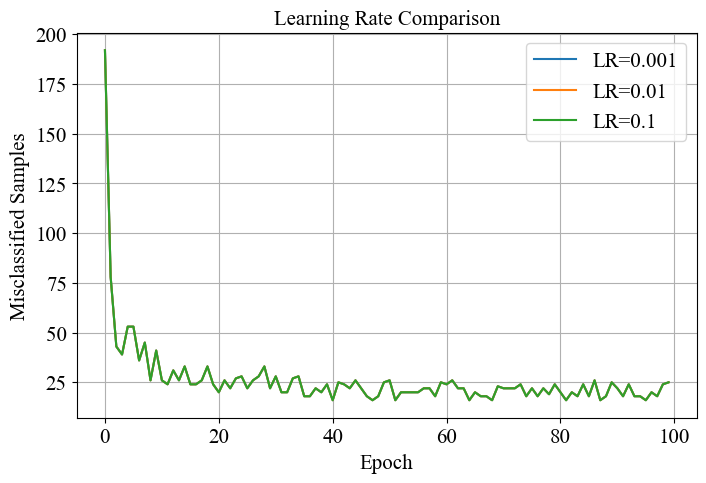

In [165]:
#Learning rate comparison
plt.figure(figsize=(8,5))

for i in range(len(lr)):
    plt.plot(mis_classified_list[i],label=f"LR={lr[i]}")

plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(True)
plt.savefig('plots/learning_rate_comparison.eps',format='eps',dpi=600,bbox_inches='tight')
plt.show()